In [202]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [203]:
df = pd.read_csv("heart_attack_prediction_india.csv")

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Patient_ID               10000 non-null  int64 
 1   State_Name               10000 non-null  object
 2   Age                      10000 non-null  int64 
 3   Gender                   10000 non-null  object
 4   Diabetes                 10000 non-null  int64 
 5   Hypertension             10000 non-null  int64 
 6   Obesity                  10000 non-null  int64 
 7   Smoking                  10000 non-null  int64 
 8   Alcohol_Consumption      10000 non-null  int64 
 9   Physical_Activity        10000 non-null  int64 
 10  Diet_Score               10000 non-null  int64 
 11  Cholesterol_Level        10000 non-null  int64 
 12  Triglyceride_Level       10000 non-null  int64 
 13  LDL_Level                10000 non-null  int64 
 14  HDL_Level                10000 non-null

In [205]:
df.describe()

,Patient_ID,Age,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,Diet_Score,Cholesterol_Level,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,5000.50000,49.394900,0.092900,0.24690,0.303700,0.301400,0.352800,0.595800,5.021700,224.753000,...,89.312000,0.403600,0.311300,5.518800,0.311000,0.152500,206.383400,1.022062e+06,0.344700,0.300700
std,2886.89568,17.280301,0.290307,0.43123,0.459878,0.458889,0.477865,0.490761,3.156394,43.359172,...,17.396486,0.490644,0.463048,2.866264,0.462926,0.359523,112.391711,5.605978e+05,0.475294,0.458585
min,1.00000,20.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,...,60.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,5.035300e+04,0.000000,0.000000
25%,2500.75000,35.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,187.000000,...,74.000000,0.000000,0.000000,3.000000,0.000000,0.000000,110.000000,5.357838e+05,0.000000,0.000000
50%,5000.50000,49.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,5.000000,226.000000,...,89.000000,0.000000,0.000000,6.000000,0.000000,0.000000,206.000000,1.021383e+06,0.000000,0.000000
75%,7500.25000,64.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,8.000000,262.000000,...,104.000000,1.000000,1.000000,8.000000,1.000000,0.000000,304.000000,1.501670e+06,1.000000,1.000000
max,10000.00000,79.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.000000,299.000000,...,119.000000,1.000000,1.000000,10.000000,1.000000,1.000000,399.000000,1.999714e+06,1.000000,1.000000


In [206]:
df.isnull().sum()

Patient_ID                 0
State_Name                 0
Age                        0
Gender                     0
Diabetes                   0
Hypertension               0
Obesity                    0
Smoking                    0
Alcohol_Consumption        0
Physical_Activity          0
Diet_Score                 0
Cholesterol_Level          0
Triglyceride_Level         0
LDL_Level                  0
HDL_Level                  0
Systolic_BP                0
Diastolic_BP               0
Air_Pollution_Exposure     0
Family_History             0
Stress_Level               0
Healthcare_Access          0
Heart_Attack_History       0
Emergency_Response_Time    0
Annual_Income              0
Health_Insurance           0
Heart_Attack_Risk          0
dtype: int64

In [207]:
df.dtypes[df.dtypes =='object']

State_Name    object
Gender        object
dtype: object

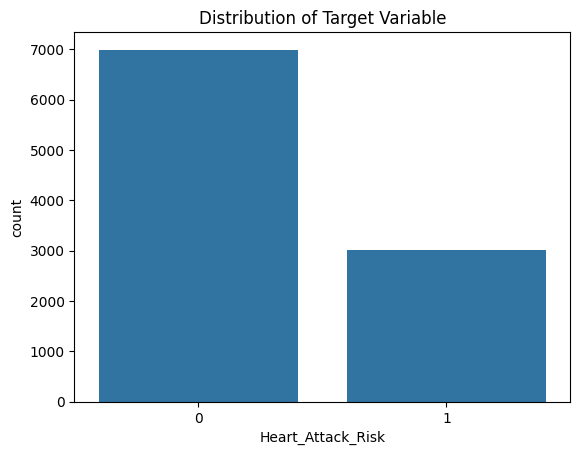

In [209]:
sns.countplot(x="Heart_Attack_Risk",data=df)
plt.title("Distribution of Target Variable")
plt.show()

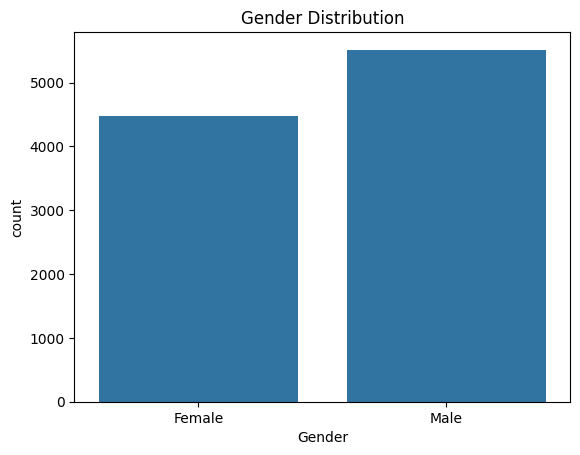

In [210]:
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()

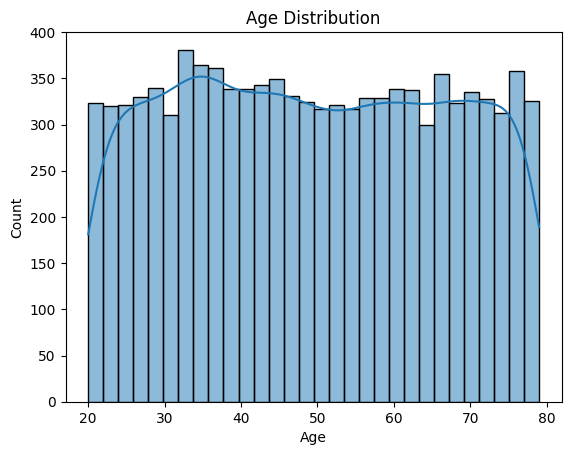

In [212]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

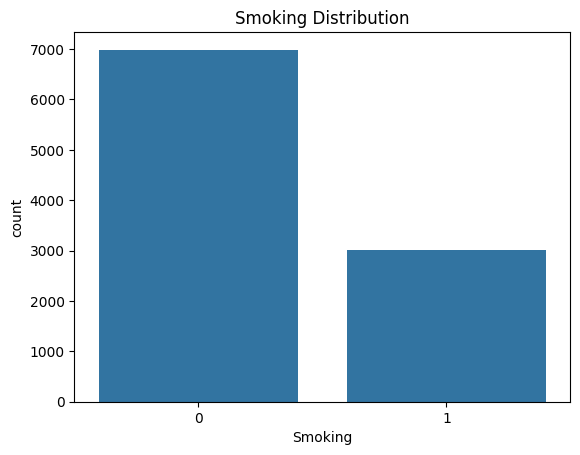

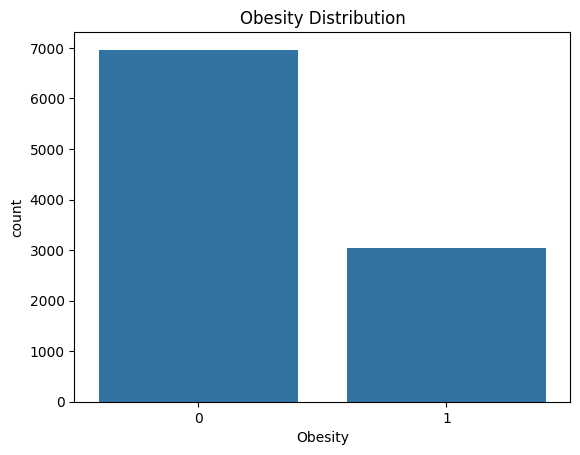

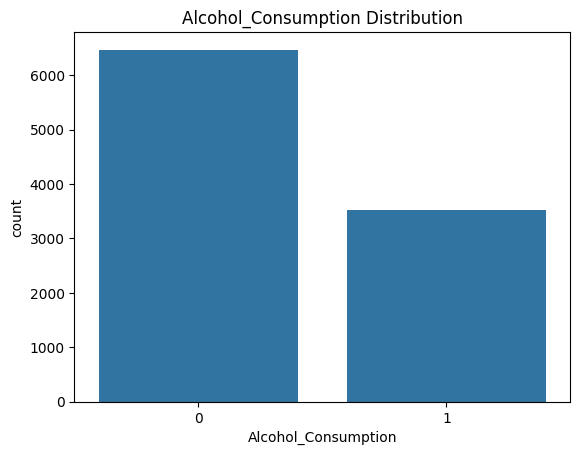

In [215]:
categorical = ['Smoking','Obesity','Alcohol_Consumption']
for col in categorical :
    sns.countplot(x=col,data=df)
    plt.title(f'{col} Distribution')
    plt.show()

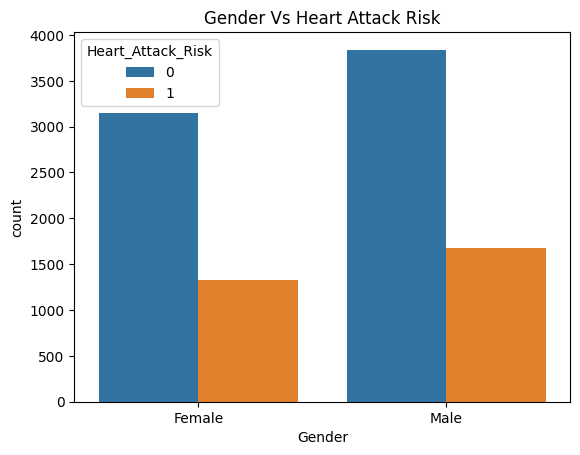

In [217]:
sns.countplot(x='Gender' ,hue='Heart_Attack_Risk',data=df)
plt.title("Gender Vs Heart Attack Risk")
plt.show()

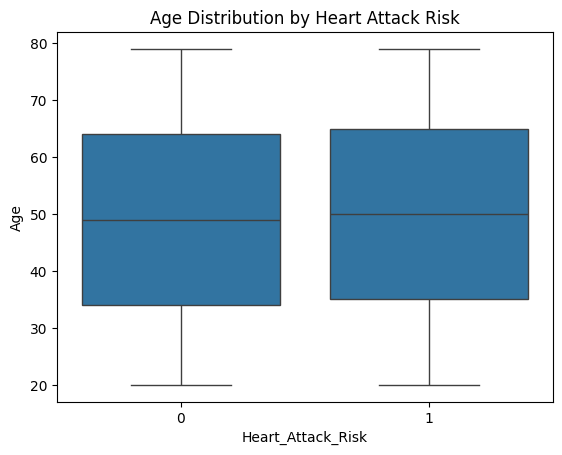

In [218]:
sns.boxplot(x="Heart_Attack_Risk" , y ="Age",data=df)
plt.title("Age Distribution by Heart Attack Risk")
plt.show()

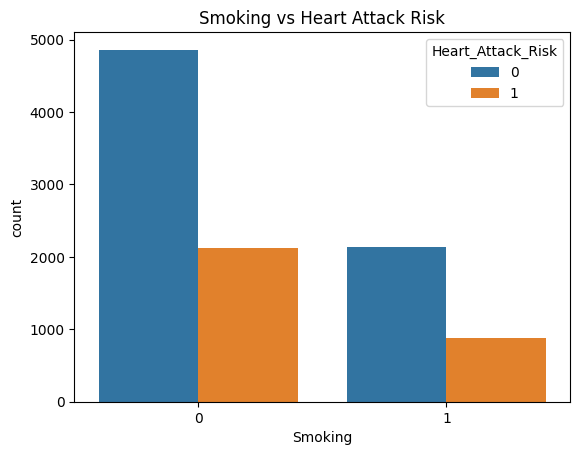

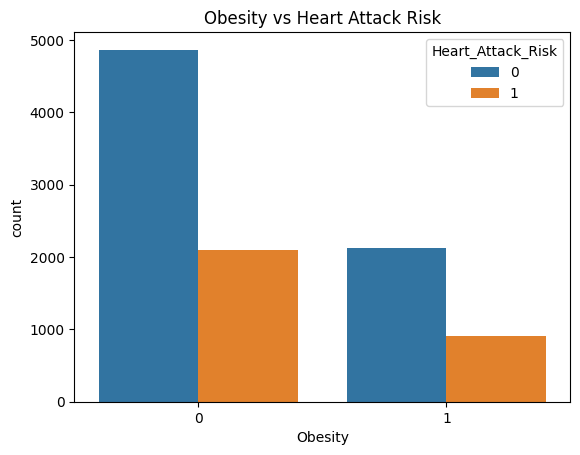

In [219]:
for col in ['Smoking','Obesity']:
    sns.countplot(x=col,hue='Heart_Attack_Risk',data=df)
    plt.title(f'{col} vs Heart Attack Risk')
    plt.show()

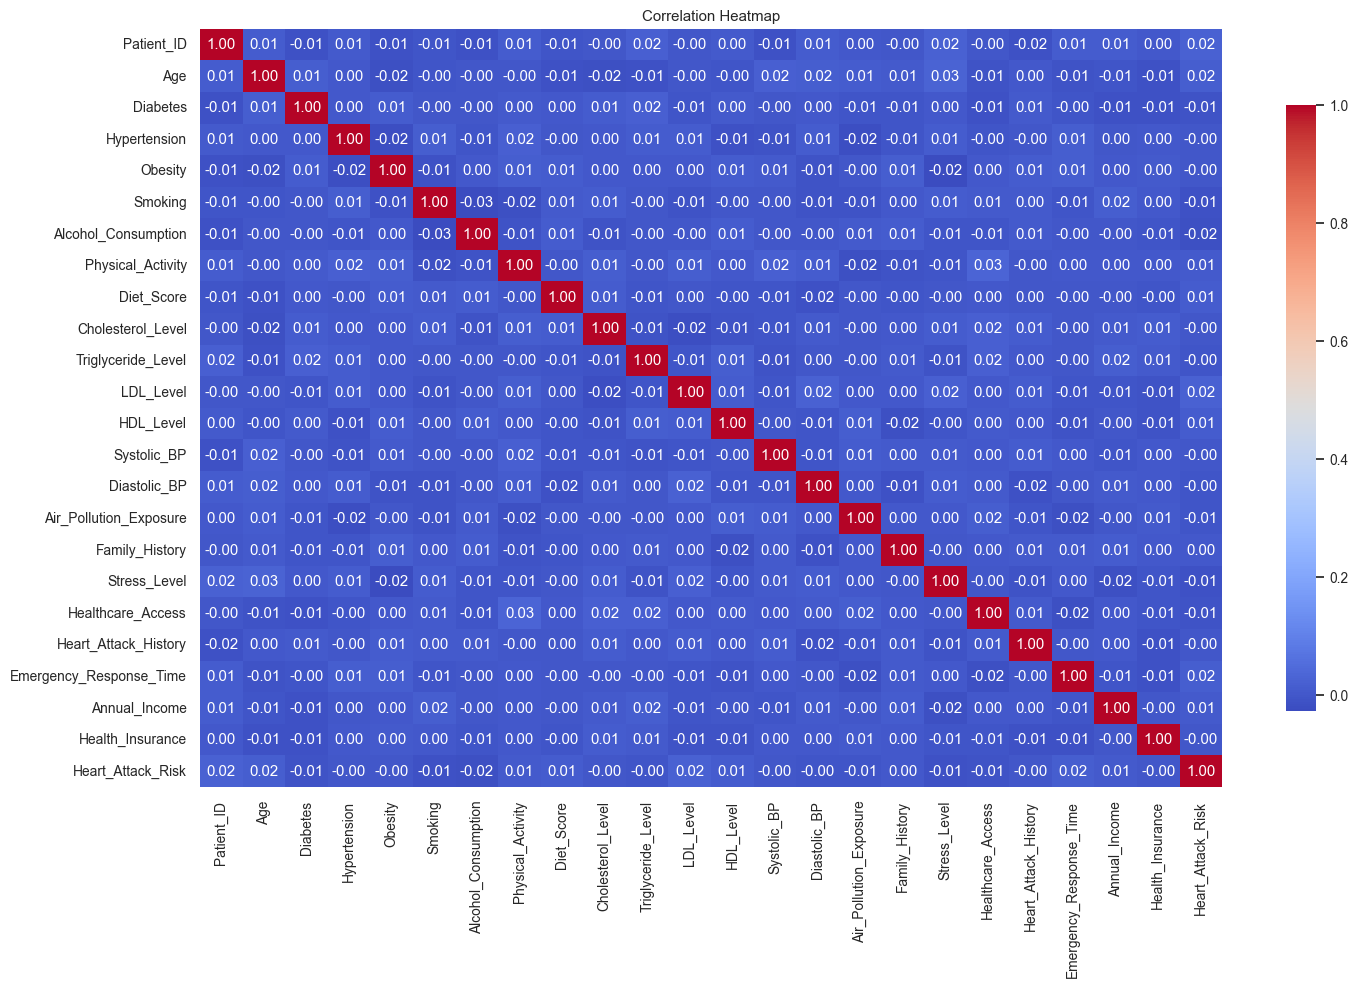

In [234]:
numeric_df= df.select_dtypes(include = 'number')
corr = numeric_df.corr()
plt.figure(figsize = (15,10))
sns.set(font_scale=0.9)
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f",square =False,cbar_kws={"shrink":.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [237]:
from sklearn.preprocessing import LabelEncoder

In [238]:
le = LabelEncoder()

In [239]:
#Label Endcoder for Gender
df['Gender'] =le.fit_transform(df['Gender'])

In [240]:
#One-hot encode for State_Name
df = pd.get_dummies(df,columns=['State_Name'],drop_first=True)

In [241]:
from sklearn.preprocessing import StandardScaler

In [242]:
X = df.drop('Heart_Attack_Risk',axis=1)
y = df['Heart_Attack_Risk']

In [243]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [244]:
from sklearn.model_selection import train_test_split

In [245]:
X_train ,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.10,random_state =42)

In [246]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [247]:
from sklearn.model_selection import GridSearchCV

In [248]:
parameters = {'C':[0.01,0.1,1,10],
              'penalty':['l1','l2'],
              'solver' : ['liblinear']}

In [249]:
from sklearn.linear_model import LogisticRegression

In [250]:
model = LogisticRegression(max_iter =1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [251]:
grid_search = GridSearchCV(model,parameters,cv=5,scoring='accuracy')

In [252]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [253]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [254]:
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

In [255]:
print("Best Parameters : " ,grid_search.best_params_)
print("Best Score: " , grid_search.best_score_)

Best Parameters :  {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score:  0.6982222222222222


In [256]:
y_proba = model.predict_proba(X_test)[:, 1]
print(y_proba[:10])


[0.34510416 0.27595476 0.35456678 0.32248846 0.31693364 0.32101498
 0.29067662 0.29193908 0.38760022 0.28954408]


In [257]:
threshold = 0.3 
y_pred_custom = (y_proba >= threshold).astype(int)

In [258]:
print("Accuracy: " ,accuracy_score(y_test,y_pred))

Accuracy:  0.709


In [259]:
print("Precision :",precision_score(y_test,y_pred,zero_division = 0))

Precision : 0.0


In [260]:
print("Recall : ",recall_score(y_test,y_pred))

Recall :  0.0


In [261]:
print("F1 score: ",f1_score(y_test,y_pred))

F1 score:  0.0


In [262]:
print("ROC-AUC: ",roc_auc_score(y_test,y_pred))

ROC-AUC:  0.5


In [263]:
print("Classification Report: ",classification_report(y_test,y_pred))

Classification Report:                precision    recall  f1-score   support

           0       0.71      1.00      0.83       709
           1       0.00      0.00      0.00       291

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.50      0.71      0.59      1000



C:\Users\arvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
